# Backtest 005b — TTM Breakout + SMF Cloud Regime Filter

Fork of **backtest_005** that adds the **Smart Money Flow Cloud** as a market-regime gate.

## Regime filter logic

| Source | Signal | Effect |
|--------|--------|--------|
| SMF Cloud | `last_signal == 1` (bull regime) | **Gate entries** — only enter TTM Breakout when bullish |
| SMF Cloud | `switch_down` (regime turns bear) | **Force exit** — close all positions immediately |

The TTM Breakout entry conditions (squeeze, momentum, KAMA slope) and exits (ATR trailing, lowest-low SL) are unchanged.  The SMF Cloud adds a higher-timeframe conviction filter on top.


In [119]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numba as nb
import vectorbt as vbt
import optuna
import talib
optuna.logging.set_verbosity(optuna.logging.WARNING)

sys.path.insert(0, str(pathlib.Path('..').resolve()))
from backend.app.services.indicators.trailing_sl import atr_trailing_nb
from backend.app.services.indicators.wiliams_vix_fix import williams_vix_fix_indicator

plt.style.use('dark_background')
print('imports ok')


imports ok


## 1. Load Data

In [120]:
REMOTE_HOST = 'http://192.168.1.3:9000'

def load_stock_data() -> pd.DataFrame:
    from deltalake import DeltaTable
    storage_options = {
        'AWS_ACCESS_KEY_ID':          'CzOwnLkEDXQy951AOqes',
        'AWS_SECRET_ACCESS_KEY':      'fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S',
        'AWS_ENDPOINT_URL':           REMOTE_HOST,
        'AWS_ALLOW_HTTP':             'true',
        'AWS_EC2_METADATA_DISABLED':  'true',
        'AWS_REGION':                 'us-east-1',
        'aws_conditional_put':        'etag',
    }
    watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
    watchlist_symbols = watchlist_df.iloc[:, 0].values
    start_date        = pd.Timestamp.now() - pd.DateOffset(years=10)

    dt = DeltaTable('s3://delta-table-storage/stocks', storage_options=storage_options)
    raw = dt.to_pandas(
        filters=[('date', '>=', start_date), ('symbol', 'in', watchlist_symbols)],
        columns=['symbol', 'date', 'close', 'open', 'high', 'low', 'volume'],
    )
    raw = raw.drop_duplicates(subset=['date', 'symbol'], keep='last')
    raw = raw.set_index(['date', 'symbol'])
    stocks = raw.unstack(level=1).bfill().ffill()
    print('Loaded from DeltaLake')
    return stocks


local_file = 'stocks_data_latest.h5'
store_key  = 'stocks'

if os.path.exists(local_file):
    print(f'Loading from local HDF5: {local_file}')
    with pd.HDFStore(local_file, mode='r') as store:
        df_raw = store[store_key]
else:
    print('HDF5 not found — loading from DeltaLake …')
    df_raw = load_stock_data()
    with pd.HDFStore(local_file, mode='w') as store:
        store.put(store_key, df_raw)

watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
watchlist_symbols = watchlist_df.iloc[:, 0].values
df_raw = df_raw.loc[:, df_raw.columns.get_level_values('symbol').isin(watchlist_symbols)]

# ── extract OHLCV DataFrames (dates × symbols) ────────────────────────────────
open_   = df_raw['open']
high    = df_raw['high']
low     = df_raw['low']
close   = df_raw['close']
volume  = df_raw['volume']

print(f'Shape: {close.shape}  |  {close.index[0]} → {close.index[-1]}')
close.tail(3)

Loading from local HDF5: stocks_data_latest.h5
Shape: (2500, 198)  |  2016-04-04 00:00:00 → 2026-04-03 00:00:00


symbol,AAA,ABB,ACB,ACV,ADS,AGG,AGR,ANV,APH,ASM,...,VNINDEX,VNM,VOS,VPB,VPG,VPI,VRE,VSC,VTP,YEG
date,,,,,,,,,,,,,,,,,,,,,
2026-04-01,7.08,14.7,23.799999,46.900002,8.63,13.00,14.90,23.85,5.59,5.72,...,1705.739990,61.299999,12.80,26.799999,4.24,58.400002,27.549999,24.250000,99.400002,10.15
2026-04-02,7.00,14.5,23.600000,46.400002,8.56,12.85,14.65,23.75,5.55,5.64,...,1695.130005,60.799999,12.65,26.250000,4.15,58.200001,27.200001,24.299999,98.300003,10.00
2026-04-03,6.94,14.5,23.500000,45.799999,8.54,12.55,14.60,23.60,5.53,5.59,...,1684.089966,60.000000,12.50,25.799999,4.02,58.000000,26.500000,23.799999,93.599998,9.94


## 2. TTM Breakout Helpers

In [121]:
# ── copied from backend/app/services/strategies/breakout_ttm.py ───────────────

@nb.njit
def shift_2d(arr, num, fill_value=np.nan):
    """Shift a 2-D array along axis 0 (time axis)."""
    result = np.empty_like(arr)
    n = arr.shape[0]
    if num > 0:
        result[:num, :] = fill_value
        result[num:, :] = arr[:n - num, :]
    elif num < 0:
        result[n + num:, :] = fill_value
        result[:n + num, :] = arr[-num:, :]
    else:
        result[:, :] = arr
    return result


@nb.njit
def count_consecutive_neg_2d(arr):
    """Count consecutive negative values per column (used for TTM momentum bars)."""
    n, m  = arr.shape
    out   = np.zeros((n, m), dtype=np.int64)
    for j in range(m):
        count = 0
        for i in range(n):
            if arr[i, j] < 0:
                count += 1
                out[i, j] = count
            else:
                count = 0
    return out


@nb.njit(cache=True)
def kama_2d(prices_np, period=10, fast=2, slow=30):
    """
    Kaufman's Adaptive Moving Average applied column-wise.
    - Efficiency Ratio (ER) = |close - close[period]| / sum(|diff(close)|, period)
    - Smoothing Constant (SC) = (ER * (fast_sc - slow_sc) + slow_sc)^2
    - KAMA[i] = KAMA[i-1] + SC * (close[i] - KAMA[i-1])
    When market is trending (ER -> 1), SC -> fast_sc (tracks quickly).
    When market is choppy   (ER -> 0), SC -> slow_sc (barely moves).
    """
    n, m    = prices_np.shape
    out     = np.full((n, m), np.nan)
    fast_sc = 2.0 / (fast + 1)
    slow_sc = 2.0 / (slow + 1)
    for j in range(m):
        kama = prices_np[period - 1, j]
        out[period - 1, j] = kama
        for i in range(period, n):
            direction  = abs(prices_np[i, j] - prices_np[i - period, j])
            volatility = 0.0
            for k in range(1, period + 1):
                volatility += abs(prices_np[i - k + 1, j] - prices_np[i - k, j])
            er = direction / volatility if volatility != 0.0 else 0.0
            sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2
            kama = kama + sc * (prices_np[i, j] - kama)
            out[i, j] = kama
    return out


@nb.njit(cache=True)
def slope_flat_2d(kama_np, slope_window, flat_threshold_pct):
    """
    Returns a boolean 2-D mask that is True where the KAMA line is
    'flat': |pct change over slope_window bars| < flat_threshold_pct.
    First slope_window rows are always False.
    """
    n, m = kama_np.shape
    out  = np.zeros((n, m), dtype=nb.boolean)
    for j in range(m):
        for i in range(slope_window, n):
            prev = kama_np[i - slope_window, j]
            if prev != 0.0 and not np.isnan(prev) and not np.isnan(kama_np[i, j]):
                slope_pct = abs((kama_np[i, j] - prev) / prev * 100.0)
                out[i, j] = slope_pct < flat_threshold_pct
    return out


print('Numba helpers compiled')


Numba helpers compiled


In [122]:
def compute_signals(
    close, high, low,
    # BB params
    bb_window:                int   = 16,
    bb_multiplier:            float = 1.0,
    bb_matype:                int   = 0,
    # Keltner params
    kc_window:                int   = 40,
    kc_multiplier:            float = 1.2,
    kc_atr_period:            int   = 10,
    # TTM oscillator params
    donichan_window:          int   = 12,
    osc_smoothing_period:     int   = 10,
    # Entry version
    entry_version:            str   = 'v3',
    consecutive_neg_threshold:int   = 7,
    # Williams VIX Fix
    william_vix_period:       int   = 20,
    # KAMA slope filter (breakout entries only)
    use_kama_slope:           bool  = True,
    kama_period:              int   = 10,
    kama_fast:                int   = 2,
    kama_slow:                int   = 30,
    kama_slope_win:           int   = 5,
    flat_threshold_pct:       float = 1.0,
):
    """
    Compute TTM Breakout entry signals.

    KAMA slope gate applies only to breakout-type entries:
      v1, v2    : full signal gated by flat KAMA slope
      v3 entry_1: squeeze-release breakout — gated by flat KAMA slope
      v3 entry_2: bottom-fishing (extended neg momentum) — NOT gated
      v3 WVF    : volatility spike / contrarian — NOT gated
    """
    BB   = vbt.IndicatorFactory.from_talib('BBANDS')
    ATR  = vbt.IndicatorFactory.from_talib('ATR')
    EMA  = vbt.IndicatorFactory.from_talib('EMA')
    SMA  = vbt.IndicatorFactory.from_talib('SMA')
    MAX  = vbt.IndicatorFactory.from_talib('MAX')
    LREG = vbt.IndicatorFactory.from_talib('LINEARREG')

    # ── indicators → numpy ────────────────────────────────────────────────────
    bb  = BB.run(close, timeperiod=bb_window,
                 nbdevup=bb_multiplier, nbdevdn=bb_multiplier, matype=bb_matype)
    atr = ATR.run(high, low, close, timeperiod=kc_atr_period)
    ema = EMA.run(close, timeperiod=kc_window)

    bb_upper_np  = bb.upperband.to_numpy()
    bb_lower_np  = bb.lowerband.to_numpy()
    ema_np       = ema.real.to_numpy()
    atr_np       = atr.real.to_numpy()
    kc_upper_np  = ema_np + kc_multiplier * atr_np
    kc_lower_np  = ema_np - kc_multiplier * atr_np

    hh  = MAX.run(high, timeperiod=donichan_window).real.to_numpy()
    ll  = MAX.run(low,  timeperiod=donichan_window).real.to_numpy()
    sma = SMA.run(close, timeperiod=donichan_window).real.to_numpy()
    close_np  = close.to_numpy()
    histogram = close_np - ((hh + ll) / 2 + sma) / 2
    ttms_np   = LREG.run(
        pd.DataFrame(histogram, index=close.index, columns=close.columns),
        timeperiod=osc_smoothing_period,
    ).real.to_numpy()

    _, _, _, wvf_signal = williams_vix_fix_indicator(
        close, high, low,
        period=william_vix_period,
        mult=bb_multiplier,
        bbl=bb_window,
        lb=20, ph=0.85, ltLB=33, mtLB=10, strength_str=1,
    )
    wvf_np = wvf_signal if isinstance(wvf_signal, np.ndarray) else wvf_signal.to_numpy()

    # ── KAMA flat-slope mask (computed once, reused across versions) ───────────
    if use_kama_slope:
        kama_np = kama_2d(close_np.astype(np.float64), kama_period, kama_fast, kama_slow)
        flat_np = slope_flat_2d(kama_np, kama_slope_win, flat_threshold_pct)
    else:
        flat_np = np.ones_like(close_np, dtype=np.bool_)  # all True → no filtering

    # ── v1: squeeze no-fire + positive momentum → full KAMA gate ──────────────
    if entry_version == 'v1':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        entries_np = no_sqz_np & (ttms_np > 0) & flat_np

    # ── v2: momentum just crossed above 0 → full KAMA gate ────────────────────
    elif entry_version == 'v2':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        ttms_1 = shift_2d(ttms_np, 1)
        ttms_2 = shift_2d(ttms_np, 2)
        ttms_3 = shift_2d(ttms_np, 3)
        crossed_now  = (ttms_1  < 0) & (ttms_np > 0)
        crossed_1ago = (ttms_2  < 0) & (ttms_1  > 0)
        crossed_2ago = (ttms_3  < 0) & (ttms_2  > 0)
        cond_2  = (ttms_np > ttms_1) & crossed_1ago
        cond_3  = (ttms_np > ttms_2) & crossed_2ago
        entries_np = no_sqz_np & (crossed_now | cond_2 | cond_3) & flat_np

    # ── v3: entry_1 (breakout) gated; entry_2 + WVF (bottom fishing) free ─────
    else:
        squeeze_diff_np = bb_upper_np - kc_upper_np
        consec_neg      = count_consecutive_neg_2d(ttms_np)

        # breakout on squeeze release — only when KAMA is flat
        entry_1 = (
            (shift_2d(squeeze_diff_np, 1) < 0)
            & (squeeze_diff_np > 0)
            & (ttms_np > 0)
            & flat_np
        )
        # bottom fishing: extended negative momentum — no KAMA filter
        entry_2 = (
            (shift_2d(squeeze_diff_np, 1) < 0)
            & (squeeze_diff_np > 0)
            & (consec_neg > consecutive_neg_threshold)
        )
        # WVF: volatility spike / contrarian — no KAMA filter
        entries_np = entry_1 | entry_2 | wvf_np

    return pd.DataFrame(entries_np, index=close.index, columns=close.columns)


def compute_exits(close, high, low, atr_multiplier=1.9, atr_period=10,
                  low_stop_lookback=5):
    """
    Returns (exits_df, sl_stop_df).

    exits_df:   ATR trailing-stop crossings used as explicit exit signals.
    sl_stop_df: per-bar relative stop-loss = (close - lowest_low) / close,
                where lowest_low = MIN(low, low_stop_lookback).
                Pass this as sl_stop= in vbt.Portfolio.from_signals so that
                on entry the stop is placed at the swing low of the last
                low_stop_lookback bars.
    """
    atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
        high, low, close, timeperiod=atr_period
    )
    ATRTrailing = vbt.IndicatorFactory(
        input_names=['close', 'atr'],
        param_names=['atr_multiplier'],
        output_names=['atr_trailing'],
    ).from_apply_func(atr_trailing_nb)
    atr_sl   = ATRTrailing.run(close, atr_raw.real, atr_multiplier=atr_multiplier)
    exits_df = close.vbt.crossed_below(atr_sl.atr_trailing)

    MIN        = vbt.IndicatorFactory.from_talib('MIN')
    lowest_low = MIN.run(low, timeperiod=low_stop_lookback).real
    sl_stop_df = ((close - lowest_low) / close).clip(lower=0)

    return exits_df, sl_stop_df


print('Signal functions defined')


Signal functions defined


## 3. Smart Money Flow Cloud (Regime Source)

In [123]:
def _alma_1d(series: np.ndarray, period: int, offset: float, sigma: float) -> np.ndarray:
    m = offset * (period - 1)
    s = period / sigma
    w = np.exp(-((np.arange(period) - m) ** 2) / (2 * s * s))
    w /= w.sum()
    out = np.full(len(series), np.nan)
    for i in range(period - 1, len(series)):
        out[i] = np.dot(w, series[i - period + 1 : i + 1])
    return out

basis_types_mapping = {
    0: 'EMA',
    1: 'ALMA',
}

def smart_money_flow_cloud(
    open_df:  pd.DataFrame,
    high_df:  pd.DataFrame,
    low_df:   pd.DataFrame,
    close_df: pd.DataFrame,
    vol_df:   pd.DataFrame,
    trend_len:    int   = 34,
    basis_type:   int   = 0,
    alma_offset:  float = 0.85,
    alma_sigma:   float = 6.0,
    basis_smooth: int   = 3,
    mf_len:       int   = 24,
    mf_smooth:    int   = 5,
    mf_power:     float = 1.2,
    atr_len:      int   = 14,
    min_mult:     float = 0.9,
    max_mult:     float = 2.2,
    dot_cooldown: int   = 12,
) -> dict:
    """Returns per-symbol dict with all SMF Cloud series."""
    results = {}
    for sym in close_df.columns:
        o = open_df[sym].values.astype(np.float64)
        h = high_df[sym].values.astype(np.float64)
        l = low_df[sym].values.astype(np.float64)
        c = close_df[sym].values.astype(np.float64)
        v = vol_df[sym].values.astype(np.float64)
        n   = len(c)
        idx = close_df.index

        if basis_types_mapping[basis_type] == 'ALMA':
            raw_o = _alma_1d(o, trend_len, alma_offset, alma_sigma)
            raw_c = _alma_1d(c, trend_len, alma_offset, alma_sigma)
        else:
            raw_o = pd.Series(o, index=idx).ewm(span=trend_len, adjust=False).mean().values
            raw_c = pd.Series(c, index=idx).ewm(span=trend_len, adjust=False).mean().values
        b_o = pd.Series(raw_o, index=idx).ewm(span=basis_smooth, adjust=False).mean().values if basis_smooth > 1 else raw_o
        b_c = pd.Series(raw_c, index=idx).ewm(span=basis_smooth, adjust=False).mean().values if basis_smooth > 1 else raw_c
        b_main = b_c

        hl       = h - l
        clv      = np.where(hl == 0, 0.0, ((c - l) - (h - c)) / hl)
        raw_flow = clv * v
        mf_num   = pd.Series(raw_flow, index=idx).rolling(mf_len).sum().values
        mf_den   = pd.Series(np.abs(raw_flow), index=idx).rolling(mf_len).sum().values
        mf_raw   = np.where(mf_den == 0, 0.0, mf_num / mf_den)
        mf_sm    = (pd.Series(mf_raw, index=idx).ewm(span=mf_smooth, adjust=False).mean().values
                    if mf_smooth > 1 else mf_raw)
        strength = np.clip(np.power(np.abs(mf_sm), mf_power), 0.0, 1.0)
        mult     = min_mult + (max_mult - min_mult) * strength

        atr    = talib.ATR(h, l, c, timeperiod=atr_len)
        upper  = b_main + atr * mult
        lower  = b_main - atr * mult

        long_cond  = (np.roll(c, 1) <= np.roll(upper, 1)) & (c > upper)
        short_cond = (np.roll(c, 1) >= np.roll(lower, 1)) & (c < lower)
        long_cond[0] = short_cond[0] = False
        last_sig    = np.zeros(n, dtype=np.int8)
        last_sig[0] = 1 if c[0] >= b_main[0] else -1
        for i in range(1, n):
            if long_cond[i]:    last_sig[i] =  1
            elif short_cond[i]: last_sig[i] = -1
            else:               last_sig[i] = last_sig[i - 1]

        switch_up   = (last_sig ==  1) & (np.roll(last_sig, 1) == -1)
        switch_down = (last_sig == -1) & (np.roll(last_sig, 1) ==  1)
        switch_up[0] = switch_down[0] = False

        results[sym] = {
            'last_signal': pd.Series(last_sig,   index=idx),
            'switch_up':   pd.Series(switch_up,  index=idx),
            'switch_down': pd.Series(switch_down,index=idx),
            'upper':       pd.Series(upper,       index=idx),
            'lower':       pd.Series(lower,       index=idx),
            'b_close':     pd.Series(b_c,         index=idx),
        }
    return results


def smf_regime_masks(smf: dict) -> tuple:
    """
    Returns (bull_regime_df, switch_down_df) — boolean DataFrames (date x symbol).

    bull_regime_df : True on bars where SMF state == +1 (bullish)
    switch_down_df : True on the bar that regime flips to bearish (force-exit signal)
    """
    syms = list(smf.keys())
    bull = pd.DataFrame({sym: smf[sym]['last_signal'] == 1  for sym in syms})
    down = pd.DataFrame({sym: smf[sym]['switch_down']       for sym in syms})
    return bull, down


print('SMF Cloud functions defined')


SMF Cloud functions defined


## 4. Baseline Run (no regime filter — same as 005)

Run the v3 strategy with default TTM params as a reference point.


In [124]:
print('Computing baseline signals (v3, default params) …')
entries_base = compute_signals(
    close, high, low,
    bb_window=16, bb_multiplier=1.0, bb_matype=0,
    kc_window=40, kc_multiplier=1.2, kc_atr_period=10,
    donichan_window=12, osc_smoothing_period=10,
    entry_version='v3',
    consecutive_neg_threshold=7,
    william_vix_period=20,
)
exits_base, sl_stop_base = compute_exits(close, high, low, atr_multiplier=1.9)

print(f'Entry signals: {entries_base.sum().sum():,}')

pf_base = vbt.Portfolio.from_signals(
    close=close,
    entries=entries_base,
    exits=exits_base,
    sl_stop=sl_stop_base,
    freq='1d',
    group_by=['symbol'],
)

print('\nBaseline portfolio stats:')
all_metrics = list(pf_base.metrics.keys())
metrics_ok  = [m for m in all_metrics if m not in ('profit_factor', 'expectancy')]
pf_base.stats(metrics=metrics_ok)


Computing baseline signals (v3, default params) …
Entry signals: 13,123

Baseline portfolio stats:


Start                                2016-04-04 00:00:00
End                                  2026-04-03 00:00:00
Period                                2500 days 00:00:00
Start Value                                        100.0
End Value                                     304.815896
Total Return [%]                              204.815896
Benchmark Return [%]                          259.869576
Max Gross Exposure [%]                             100.0
Total Fees Paid                                      0.0
Max Drawdown [%]                               44.700006
Max Drawdown Duration                  916 days 16:00:00
Total Trades                                   53.106061
Total Closed Trades                            52.479798
Total Open Trades                               0.626263
Open Trade PnL                                  3.653158
Win Rate [%]                                   39.173964
Best Trade [%]                                 65.039975
Worst Trade [%]                

## 5. Baseline + SMF Regime Filter (default SMF params)

Same TTM v3 default params, but entries are gated by `last_signal == 1` and `switch_down` forces exit.


In [125]:
print('Computing SMF regime (default params) ...')
smf_default = smart_money_flow_cloud(
    open_, high, low, close, volume,
    trend_len=34, basis_smooth=3,
    mf_len=24, mf_smooth=5, mf_power=1.2,
    atr_len=14, min_mult=0.9, max_mult=2.2,
)
bull_default, switch_down_default = smf_regime_masks(smf_default)

# Gate TTM entries with bull regime
entries_base_filtered = entries_base & bull_default
# Add switch_down as forced exit on top of ATR trailing
exits_base_filtered   = exits_base

pf_base_smf = vbt.Portfolio.from_signals(
    close=close,
    entries   = entries_base_filtered,
    exits     = exits_base_filtered,
    sl_stop   = sl_stop_base,
    freq      = '1d',
    group_by  = ['symbol'],
    cash_sharing = False,
)
sv_bas     = pf_base.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
sv_bas_smf = pf_base_smf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
print(f'Baseline (no filter) |  Sharpe mean={sv_bas.mean():.3f}  >1: {(sv_bas>1).sum()}/{len(sv_bas)}')
print(f'Baseline + SMF gate  |  Sharpe mean={sv_bas_smf.mean():.3f}  >1: {(sv_bas_smf>1).sum()}/{len(sv_bas_smf)}')
print(f'Entry signals filtered: {entries_base.sum().sum():,} -> {entries_base_filtered.sum().sum():,}')


Computing SMF regime (default params) ...
Baseline (no filter) |  Sharpe mean=0.554  >1: 24/198
Baseline + SMF gate  |  Sharpe mean=0.321  >1: 8/197
Entry signals filtered: 13,123 -> 4,564


## 6. Optuna Optimisation — Fixed TTM + SMF Regime

Optimises both TTM Breakout params **and** SMF Cloud regime params jointly.
Objectives: **(Mean Total Return %, Mean Sortino Ratio)**


In [ ]:
FIXED_TTM_PARAMS = {
    'v1': {
        'bb_window': 15,
        'bb_multiplier': 1.0,
        'bb_matype': 3,
        'kc_window': 38,
        'kc_multiplier': 1.3,
        'kc_atr_period': 5,
        'donichan_window': 9,
        'osc_smoothing_period': 11,
        'atr_period': 6,
        'atr_multiplier': 2.0,
        'low_stop_lookback': 9,
        'consecutive_neg_threshold': 13,
        'william_vix_period': 17,
        'kama_period': 8,
        'kama_fast': 5,
        'kama_slow': 41,
        'kama_slope_win': 5,
        'flat_threshold_pct': 2.7,
    },
    'v2': {
        'bb_window': 15,
        'bb_multiplier': 1.3,
        'bb_matype': 0,
        'kc_window': 52,
        'kc_multiplier': 1.2000000000000002,
        'kc_atr_period': 14,
        'donichan_window': 9,
        'osc_smoothing_period': 13,
        'atr_period': 7,
        'atr_multiplier': 2.6,
        'low_stop_lookback': 3,
        'consecutive_neg_threshold': 8,
        'william_vix_period': 18,
        'kama_period': 11,
        'kama_fast': 2,
        'kama_slow': 36,
        'kama_slope_win': 5,
        'flat_threshold_pct': 2.5,
    },
    'v3': {
        'bb_window': 10,
        'bb_multiplier': 1.2000000000000002,
        'bb_matype': 3,
        'kc_window': 39,
        'kc_multiplier': 1.6,
        'kc_atr_period': 6,
        'donichan_window': 14,
        'osc_smoothing_period': 15,
        'atr_period': 11,
        'atr_multiplier': 2.6,
        'low_stop_lookback': 5,
        'consecutive_neg_threshold': 4,
        'william_vix_period': 17,
        'kama_period': 16,
        'kama_fast': 5,
        'kama_slow': 39,
        'kama_slope_win': 5,
        'flat_threshold_pct': 1.8,
    },
}


def make_objective_smf(version: str):
    fixed = FIXED_TTM_PARAMS[version]

    def objective(trial):
        # ── Only optimise SMF params; TTM is fixed from prior optimisation ──
        smf_trend_len  = trial.suggest_int  ('smf_trend_len',  10, 55)
        smf_mf_len     = trial.suggest_int  ('smf_mf_len',     10, 40)
        smf_mf_smooth  = trial.suggest_int  ('smf_mf_smooth',   1, 10)
        smf_mf_power   = trial.suggest_float('smf_mf_power',   0.5, 2.5, step=0.1)
        smf_atr_len    = trial.suggest_int  ('smf_atr_len',     7, 21)
        smf_min_mult   = trial.suggest_float('smf_min_mult',    0.5, 1.5, step=0.1)
        smf_max_mult   = trial.suggest_float('smf_max_mult',    1.5, 3.5, step=0.1)
        smf_basis_type = trial.suggest_int  ('smf_basis_type', 0, 1)
        try:
            entries = compute_signals(
                close, high, low,
                bb_window=fixed['bb_window'],
                bb_multiplier=fixed['bb_multiplier'],
                bb_matype=fixed['bb_matype'],
                kc_window=fixed['kc_window'],
                kc_multiplier=fixed['kc_multiplier'],
                kc_atr_period=fixed['kc_atr_period'],
                donichan_window=fixed['donichan_window'],
                osc_smoothing_period=fixed['osc_smoothing_period'],
                entry_version=version,
                consecutive_neg_threshold=fixed['consecutive_neg_threshold'],
                william_vix_period=fixed['william_vix_period'],
                use_kama_slope=True,
                kama_period=fixed['kama_period'],
                kama_fast=fixed['kama_fast'],
                kama_slow=fixed['kama_slow'],
                kama_slope_win=fixed['kama_slope_win'],
                flat_threshold_pct=fixed['flat_threshold_pct'],
            )
            exits, sl_stop_df = compute_exits(
                close, high, low,
                atr_multiplier=fixed['atr_multiplier'],
                atr_period=fixed['atr_period'],
                low_stop_lookback=fixed['low_stop_lookback'],
            )
            smf = smart_money_flow_cloud(
                open_, high, low, close, volume,
                trend_len=smf_trend_len, mf_len=smf_mf_len,
                mf_smooth=smf_mf_smooth, mf_power=smf_mf_power,
                atr_len=smf_atr_len, min_mult=smf_min_mult, max_mult=smf_max_mult,
                basis_type=smf_basis_type,
            )
            bull_regime, _ = smf_regime_masks(smf)
            entries = entries & bull_regime

            pf = vbt.Portfolio.from_signals(
                close=close, entries=entries, exits=exits,
                freq='1d', group_by=['symbol'],
                cash_sharing=False, sl_stop=sl_stop_df,
            )
            total_ret = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
            sortino   = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
            sharpe    = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
            if len(total_ret) == 0:
                return -999.0, -999.0
            mean_ret  = float(total_ret.mean() * 100)
            mean_sort = float(sortino.mean()) if len(sortino) > 0 else -999.0
            if len(sharpe) > 0 and (sharpe > 0).mean() < 0.3:
                mean_ret  *= 0.5
                mean_sort *= 0.5
            return mean_ret, mean_sort
        except Exception:
            return -999.0, -999.0

    return objective


N_TRIALS_PER_VERSION = 500

studies_smf = {}
for ver in ['v1', 'v2', 'v3']:
    print(f'\n-- Optimising {ver} SMF-only ({N_TRIALS_PER_VERSION} trials) --')
    s = optuna.create_study(
        directions = ['maximize', 'maximize'],
        study_name = f'ttm_{ver}_smf',
        sampler    = optuna.samplers.NSGAIISampler(seed=42),
    )
    s.optimize(make_objective_smf(ver), n_trials=N_TRIALS_PER_VERSION,
               show_progress_bar=True)
    studies_smf[ver] = s
    print(f'  Pareto front: {len(s.best_trials)} trials')

print('\nAll studies done.')



-- Optimising v1 SMF-only (500 trials) --


  0%|          | 0/500 [00:00<?, ?it/s]

## 7. Select Best Params per Version

In [ ]:
SELECTION = 'balanced'

def pick_best(study, selection=SELECTION):
    if selection == 'best_return':
        return max(study.best_trials, key=lambda t: t.values[0])
    if selection == 'best_sortino':
        return max(study.best_trials, key=lambda t: t.values[1])
    def score(t):
        return 0.4 * (t.values[0] + 100) / 200 + 0.6 * (t.values[1] + 10) / 20
    return max(study.best_trials, key=score)


best_trials_smf = {ver: pick_best(studies_smf[ver]) for ver in ['v1', 'v2', 'v3']}
best_params_smf = {
    ver: {**FIXED_TTM_PARAMS[ver], **t.params}
    for ver, t in best_trials_smf.items()
}

for ver, t in best_trials_smf.items():
    print(f'{ver}  Return={t.values[0]:.2f}%  Sortino={t.values[1]:.3f}')
    smf_keys = [k for k in t.params if k.startswith('smf_')]
    print('  SMF params:', {k: t.params[k] for k in smf_keys})
    print('  Fixed TTM params:', FIXED_TTM_PARAMS[ver])


v1  Return=318.88%  Sortino=0.973
  SMF params: {'smf_trend_len': 13, 'smf_mf_len': 26, 'smf_mf_smooth': 1, 'smf_mf_power': 1.8, 'smf_atr_len': 16, 'smf_min_mult': 0.5, 'smf_max_mult': 2.7}
  Fixed TTM params: {'bb_window': 15, 'bb_multiplier': 1.0, 'bb_matype': 3, 'kc_window': 38, 'kc_multiplier': 1.3, 'kc_atr_period': 5, 'donichan_window': 9, 'osc_smoothing_period': 11, 'atr_period': 6, 'atr_multiplier': 2.0, 'low_stop_lookback': 9, 'consecutive_neg_threshold': 13, 'william_vix_period': 17, 'kama_period': 8, 'kama_fast': 5, 'kama_slow': 41, 'kama_slope_win': 5, 'flat_threshold_pct': 2.7}
v2  Return=265.29%  Sortino=0.827
  SMF params: {'smf_trend_len': 15, 'smf_mf_len': 15, 'smf_mf_smooth': 1, 'smf_mf_power': 2.1, 'smf_atr_len': 16, 'smf_min_mult': 0.6, 'smf_max_mult': 2.9000000000000004}
  Fixed TTM params: {'bb_window': 15, 'bb_multiplier': 1.3, 'bb_matype': 0, 'kc_window': 52, 'kc_multiplier': 1.2000000000000002, 'kc_atr_period': 14, 'donichan_window': 9, 'osc_smoothing_period': 1

## 8. Pareto Fronts — All Versions

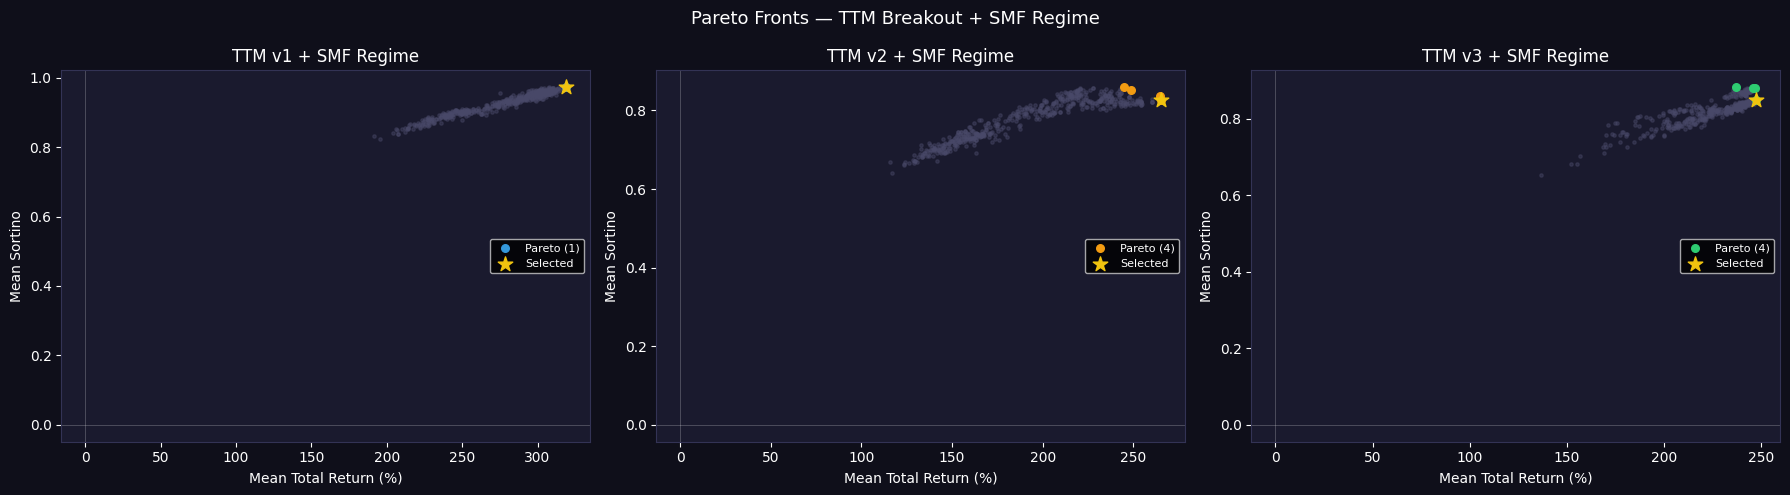

In [ ]:
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f1a')

for ax, ver in zip(axes, ['v1', 'v2', 'v3']):
    study = studies_smf[ver]
    col   = COLORS[ver]
    ax.set_facecolor('#1a1a2e')
    all_v = [(t.values[0], t.values[1]) for t in study.trials
             if t.values and t.values[0] != -999.0]
    pf_v  = [(t.values[0], t.values[1]) for t in study.best_trials]
    ax.scatter([v[0] for v in all_v], [v[1] for v in all_v],
               color='#4a4a6a', s=6, alpha=0.4)
    ax.scatter([v[0] for v in pf_v],  [v[1] for v in pf_v],
               color=col, s=30, zorder=5, label=f'Pareto ({len(pf_v)})')
    bx, by = best_trials_smf[ver].values
    ax.scatter([bx], [by], color='#f1c40f', s=120, marker='*', zorder=6, label='Selected')
    ax.axvline(0, color='white', lw=0.5, alpha=0.3)
    ax.axhline(0, color='white', lw=0.5, alpha=0.3)
    ax.set_title(f'TTM {ver} + SMF Regime', color='white')
    ax.set_xlabel('Mean Total Return (%)', color='white')
    ax.set_ylabel('Mean Sortino', color='white')
    ax.tick_params(colors='white')
    ax.legend(fontsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor('#333355')

plt.suptitle('Pareto Fronts — TTM Breakout + SMF Regime', color='white', fontsize=13)
plt.tight_layout()
plt.show()


## 9. Final Backtest — Optimised v1 / v2 / v3 + SMF Regime

In [ ]:
portfolios_smf = {}

for ver in ['v1', 'v2', 'v3']:
    p = best_params_smf[ver]
    print(f'Running optimised {ver} + SMF ...')
    entries = compute_signals(
        close, high, low,
        bb_window                 = p['bb_window'],
        bb_multiplier             = p['bb_multiplier'],
        bb_matype                 = p.get('bb_matype', 0),
        kc_window                 = p['kc_window'],
        kc_multiplier             = p['kc_multiplier'],
        kc_atr_period             = p['kc_atr_period'],
        donichan_window           = p['donichan_window'],
        osc_smoothing_period      = p['osc_smoothing_period'],
        entry_version             = ver,
        consecutive_neg_threshold = p.get('consecutive_neg_threshold', 7),
        william_vix_period        = p.get('william_vix_period',        20),
        use_kama_slope            = True,
        kama_period               = p.get('kama_period',               10),
        kama_fast                 = p.get('kama_fast',                  2),
        kama_slow                 = p.get('kama_slow',                 30),
        kama_slope_win            = p.get('kama_slope_win',             5),
        flat_threshold_pct        = p.get('flat_threshold_pct',         1.0),
    )
    exits, sl_stop_df = compute_exits(
        close, high, low,
        atr_multiplier    = p['atr_multiplier'],
        atr_period        = p.get('atr_period', 10),
        low_stop_lookback = p.get('low_stop_lookback', 5),
    )
    smf = smart_money_flow_cloud(
        open_, high, low, close, volume,
        trend_len  = p['smf_trend_len'],
        mf_len     = p['smf_mf_len'],
        mf_smooth  = p['smf_mf_smooth'],
        mf_power   = p['smf_mf_power'],
        atr_len    = p['smf_atr_len'],
        min_mult   = p['smf_min_mult'],
        max_mult   = p['smf_max_mult'],
        basis_type = p['smf_basis_type'],
    )
    bull_regime, switch_down = smf_regime_masks(smf)
    entries = entries & bull_regime
    exits   = exits.vbt   | switch_down.vbt

    pf = vbt.Portfolio.from_signals(
        close=close, entries=entries, exits=exits,
        freq='1d', group_by=['symbol'],
        cash_sharing=False, sl_stop=sl_stop_df,
    )
    portfolios_smf[ver] = pf
    n_sig = int(entries.sum().sum())
    print(f'  signals={n_sig:,}  trades={int(pf.trades.count().sum()):,}')

print('\nAll done.')


Running optimised v1 + SMF ...
  signals=77,282  trades=9,718
Running optimised v2 + SMF ...
  signals=24,692  trades=7,569
Running optimised v3 + SMF ...
  signals=12,358  trades=6,921

All done.


In [ ]:
portfolios_ttm = {}
for ver in ['v1', 'v2', 'v3']:
    p = FIXED_TTM_PARAMS[ver]
    print(f'Running optimised {ver} (TTM, no SMF) ...')
    entries = compute_signals(
        close, high, low,
        bb_window                 = p['bb_window'],
        bb_multiplier             = p['bb_multiplier'],
        bb_matype                 = p.get('bb_matype', 0),
        kc_window                 = p['kc_window'],
        kc_multiplier             = p['kc_multiplier'],
        kc_atr_period             = p['kc_atr_period'],
        donichan_window           = p['donichan_window'],
        osc_smoothing_period      = p['osc_smoothing_period'],
        entry_version             = ver,
        consecutive_neg_threshold = p.get('consecutive_neg_threshold', 7),
        william_vix_period        = p.get('william_vix_period',        20),
        use_kama_slope            = True,
        kama_period               = p.get('kama_period',               10),
        kama_fast                 = p.get('kama_fast',                  2),
        kama_slow                 = p.get('kama_slow',                 30),
        kama_slope_win            = p.get('kama_slope_win',             5),
        flat_threshold_pct        = p.get('flat_threshold_pct',         1.0),
    )
    exits, sl_stop_df = compute_exits(
        close, high, low,
        atr_multiplier    = p['atr_multiplier'],
        atr_period        = p.get('atr_period', 10),
        low_stop_lookback = p.get('low_stop_lookback', 5),
    )
    pf = vbt.Portfolio.from_signals(
        close=close, entries=entries, exits=exits,
        freq='1d', group_by=['symbol'],
        cash_sharing=False, sl_stop=sl_stop_df,
    )
    portfolios_ttm[ver] = pf
    n_sig = int(entries.sum().sum())
    print(f'  signals={n_sig:,}  trades={int(pf.trades.count().sum()):,}')

Running optimised v1 (TTM, no SMF) ...
  signals=97,375  trades=11,093
Running optimised v2 (TTM, no SMF) ...
  signals=37,492  trades=10,146
Running optimised v3 (TTM, no SMF) ...
  signals=22,251  trades=10,821


## 10. Comparison — Stats Table

In [ ]:
def version_stats(label, pf):
    s   = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    so  = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    cm  = pf.calmar_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    tr  = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
    mdd = pf.max_drawdown().replace([np.inf, -np.inf], np.nan).dropna()
    wr  = pf.trades.win_rate().replace([np.inf, -np.inf], np.nan).dropna()
    return {
        'Strategy':         label,
        'Sharpe mean':      round(s.mean(),   3),
        'Sharpe median':    round(s.median(), 3),
        'Sharpe > 0':       f'{(s > 0).sum()}/{len(s)}',
        'Sharpe > 1':       f'{(s > 1).sum()}/{len(s)}',
        'Sortino mean':     round(so.mean(),  3),
        'Calmar mean':      round(cm.mean(),  3),
        'Total Ret mean':   f'{tr.mean()*100:.1f}%',
        'Max DD mean':      f'{mdd.mean()*100:.1f}%',
        'Win Rate mean':    f'{wr.mean()*100:.1f}%',
        'Trades median':    int(pf.trades.count().median()),
    }

rows = [
    version_stats('Baseline (no filter)',     pf_base),
    version_stats('Baseline + SMF gate',      pf_base_smf),
]
if portfolios_ttm:
    rows += [
        version_stats(f'Opt {ver} (TTM)', portfolios_ttm[ver])
        for ver in ['v1', 'v2', 'v3']
    ]
rows += [
    version_stats(f'Opt {ver} + SMF', portfolios_smf[ver])
    for ver in ['v1', 'v2', 'v3']
]
stats_df = pd.DataFrame(rows).set_index('Strategy').T
stats_df


Strategy,Baseline (no filter),Baseline + SMF gate,Opt v1 (TTM),Opt v2 (TTM),Opt v3 (TTM),Opt v1 + SMF,Opt v2 + SMF,Opt v3 + SMF
Sharpe mean,0.554,0.324,0.669,0.633,0.646,0.612,0.518,0.538
Sharpe median,0.55,0.326,0.697,0.64,0.657,0.619,0.526,0.52
Sharpe > 0,187/198,164/197,192/198,187/198,189/198,185/198,175/198,179/198
Sharpe > 1,24/198,8/197,31/198,35/198,33/198,31/198,23/198,27/198
Sortino mean,0.864,0.537,1.053,0.997,1.028,0.973,0.827,0.848
Calmar mean,0.349,0.202,0.472,0.465,0.429,0.433,0.372,0.355
Total Ret mean,204.8%,50.2%,417.9%,441.0%,422.0%,318.9%,265.3%,247.2%
Max DD mean,-44.7%,-30.1%,-45.7%,-44.9%,-50.5%,-41.8%,-40.9%,-42.8%
Win Rate mean,39.6%,38.5%,41.0%,32.9%,38.3%,40.2%,36.0%,37.5%
Trades median,57,19,60,55,58,53,41,37


## 11. Sharpe Distribution — Regime Filter vs No Filter

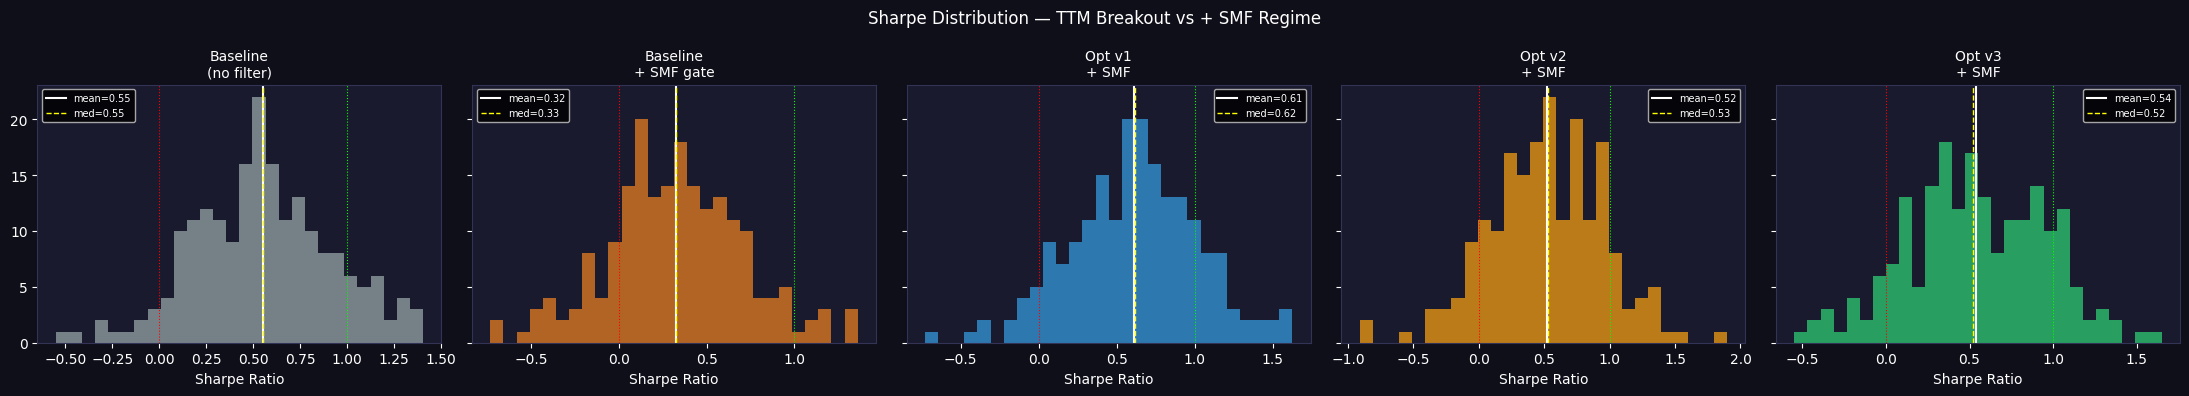

In [ ]:
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}
portfolios_ttm = globals().get('portfolios_ttm', {})

entries_list = [
    ('Baseline\n(no filter)', pf_base,       '#95a5a6'),
    ('Baseline\n+ SMF gate',  pf_base_smf,   '#e67e22'),
]
if portfolios_ttm:
    entries_list += [(f'Opt {ver}\n(TTM)', portfolios_ttm[ver], COLORS[ver]) for ver in ['v1', 'v2', 'v3']]
entries_list += [(f'Opt {ver}\n+ SMF', portfolios_smf[ver], COLORS[ver]) for ver in ['v1', 'v2', 'v3']]

n = len(entries_list)
fig, axes = plt.subplots(1, n, figsize=(max(22, 3.0 * n), 4), sharey=True)
fig.patch.set_facecolor('#0f0f1a')

for ax, (name, pf, col) in zip(axes, entries_list):
    sv = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    ax.set_facecolor('#1a1a2e')
    ax.hist(sv, bins=28, color=col, alpha=0.75, edgecolor='none')
    ax.axvline(sv.mean(),   color='white',  lw=1.5, ls='-',  label=f'mean={sv.mean():.2f}')
    ax.axvline(sv.median(), color='yellow', lw=1.0, ls='--', label=f'med={sv.median():.2f}')
    ax.axvline(0, color='red',  lw=0.8, ls=':')
    ax.axvline(1, color='lime', lw=0.8, ls=':')
    ax.set_title(name, color='white', fontsize=10)
    ax.set_xlabel('Sharpe Ratio', color='white')
    ax.tick_params(colors='white')
    ax.legend(fontsize=7)
    for sp in ax.spines.values(): sp.set_edgecolor('#333355')

plt.suptitle('Sharpe Distribution — TTM Breakout vs + SMF Regime', color='white', fontsize=12)
plt.tight_layout()
plt.show()


## 12. Delta Sharpe vs Baseline (No Filter)

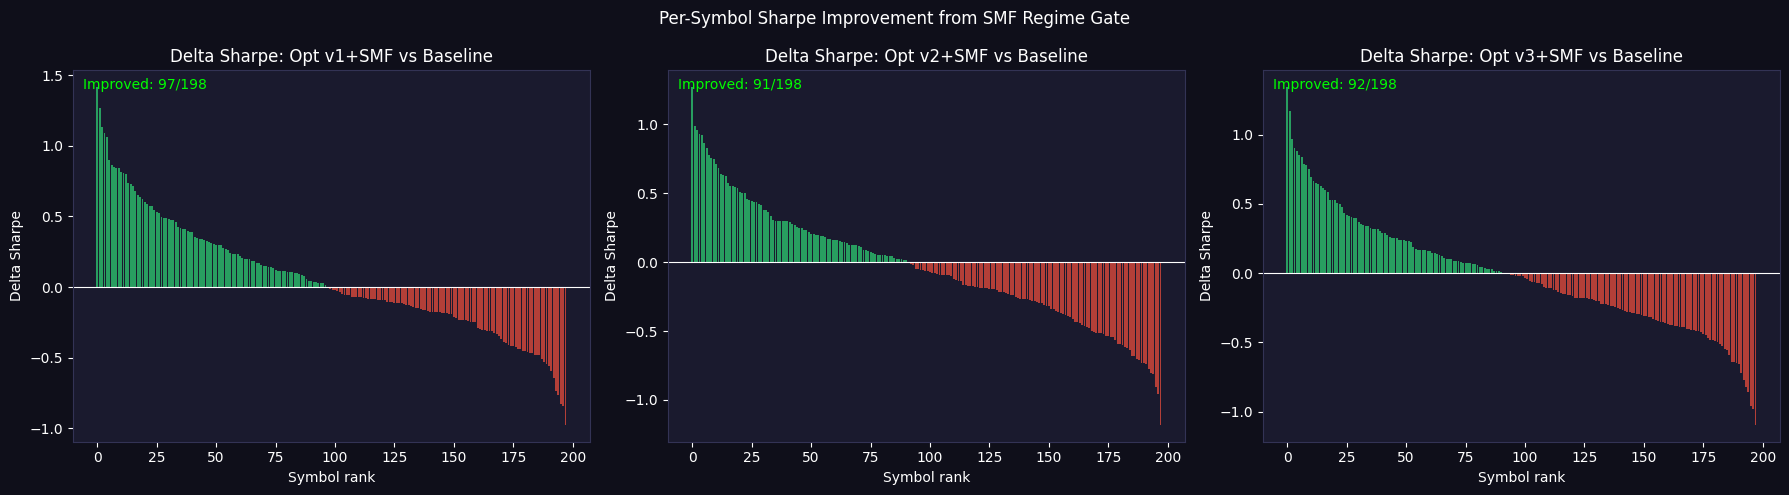

In [ ]:
# Per-symbol Sharpe improvement from adding SMF regime filter
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f1a')

sr_base = pf_base.sharpe_ratio().replace([np.inf, -np.inf], np.nan)

for ax, ver in zip(axes, ['v1', 'v2', 'v3']):
    pf     = portfolios_smf[ver]
    sr_opt = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan)
    delta  = (sr_opt - sr_base).dropna().sort_values(ascending=False)
    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in delta]
    ax.set_facecolor('#1a1a2e')
    ax.bar(range(len(delta)), delta.values, color=colors, alpha=0.75)
    ax.axhline(0, color='white', lw=0.8)
    ax.set_title(f'Delta Sharpe: Opt {ver}+SMF vs Baseline', color='white')
    ax.set_xlabel('Symbol rank', color='white')
    ax.set_ylabel('Delta Sharpe', color='white')
    ax.tick_params(colors='white')
    improved = (delta > 0).sum()
    ax.text(0.02, 0.95, f'Improved: {improved}/{len(delta)}',
            transform=ax.transAxes, color='lime', fontsize=10)
    for sp in ax.spines.values(): sp.set_edgecolor('#333355')

plt.suptitle('Per-Symbol Sharpe Improvement from SMF Regime Gate', color='white', fontsize=12)
plt.tight_layout()
plt.show()


## 13. Single-Symbol — TTM Entries with SMF Regime Overlay

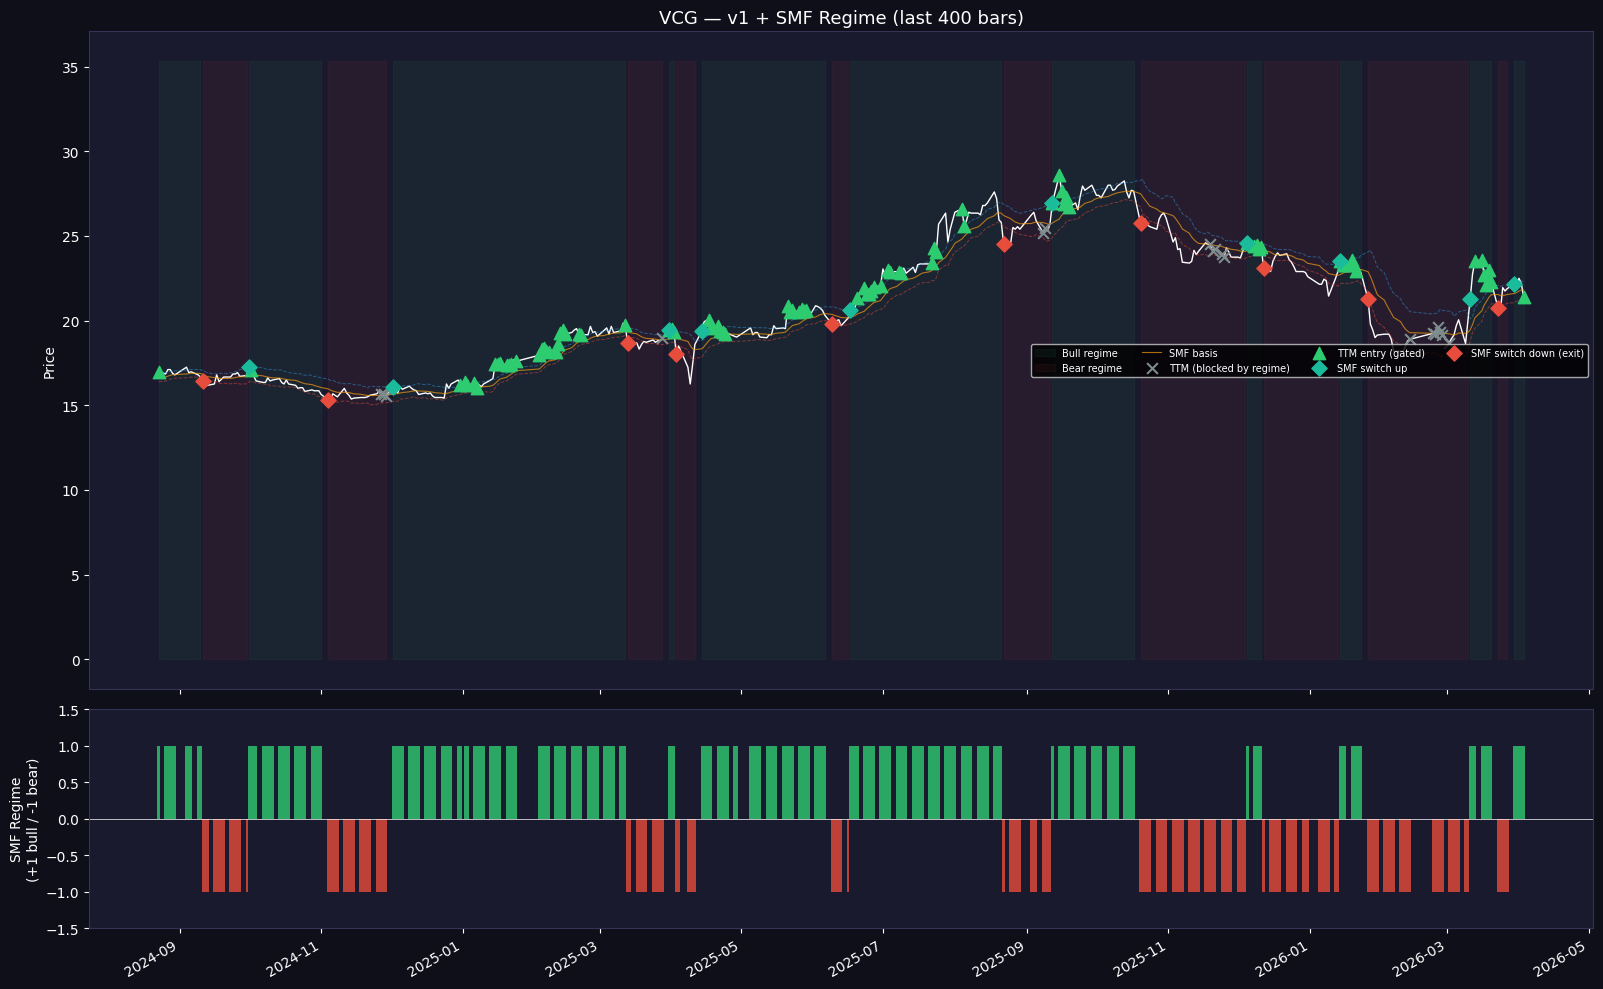

VCG | Sharpe: 0.225  Total Ret: 16.0%


In [ ]:
# Change to inspect any symbol
VER    = 'v1'
SYMBOL = 'VCG'
LOOKBACK_DAYS = 400

p      = best_params_smf[VER]
smf_s  = smart_money_flow_cloud(
    open_, high, low, close, volume,
    trend_len=p['smf_trend_len'], mf_len=p['smf_mf_len'],
    mf_smooth=p['smf_mf_smooth'], mf_power=p['smf_mf_power'],
    atr_len=p['smf_atr_len'], min_mult=p['smf_min_mult'], max_mult=p['smf_max_mult'],
)
sym_smf    = smf_s[SYMBOL]
last_sig   = sym_smf['last_signal'].values
switch_up  = sym_smf['switch_up'].values.astype(bool)
switch_dn  = sym_smf['switch_down'].values.astype(bool)
upper      = sym_smf['upper'].values
lower_band = sym_smf['lower'].values
b_c        = sym_smf['b_close'].values

# TTM entries without regime filter
ttm_entries_raw = compute_signals(
    close, high, low,
    bb_window=p['bb_window'], bb_multiplier=p['bb_multiplier'], bb_matype=p.get('bb_matype', 0),
    kc_window=p['kc_window'], kc_multiplier=p['kc_multiplier'],
    kc_atr_period=p['kc_atr_period'],
    donichan_window=p['donichan_window'], osc_smoothing_period=p['osc_smoothing_period'],
    entry_version=VER,
    consecutive_neg_threshold=p.get('consecutive_neg_threshold',7),
    william_vix_period=p.get('william_vix_period',20),
    use_kama_slope=True,
    kama_period=p.get('kama_period',10), kama_fast=p.get('kama_fast',2),
    kama_slow=p.get('kama_slow',30), kama_slope_win=p.get('kama_slope_win',5),
    flat_threshold_pct=p.get('flat_threshold_pct',1.0),
)
ttm_raw    = ttm_entries_raw[SYMBOL].values.astype(bool)
ttm_gated  = (ttm_entries_raw[SYMBOL] & (sym_smf['last_signal'] == 1)).values.astype(bool)

c_sym   = close[SYMBOL].values
dates   = close.index
n_show  = min(LOOKBACK_DAYS, len(dates))
sl_     = slice(-n_show, None)
dates_s = dates[sl_]
def s(arr): return arr[sl_]

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor('#0f0f1a')

ax = axes[0]
ax.set_facecolor('#1a1a2e')
# Shade regime periods
bull_mask = s(last_sig) == 1
ax.fill_between(dates_s, ax.get_ylim()[0] if ax.get_ylim()[0] != 0 else 0,
                c_sym.max(),
                where=bull_mask, color='#2ecc71', alpha=0.06, label='Bull regime')
ax.fill_between(dates_s, 0, c_sym.max(),
                where=~bull_mask, color='#e74c3c', alpha=0.06, label='Bear regime')
ax.plot(dates_s, s(c_sym),      color='white',   lw=1.0)
ax.plot(dates_s, s(b_c),        color='#f39c12', lw=0.8, alpha=0.7, label='SMF basis')
ax.plot(dates_s, s(upper),      color='#3498db', lw=0.7, ls='--', alpha=0.5)
ax.plot(dates_s, s(lower_band), color='#e74c3c', lw=0.7, ls='--', alpha=0.5)
# TTM entries blocked by regime (grey x)
blocked = s(ttm_raw) & ~s(ttm_gated)
ax.scatter(dates_s[blocked], s(c_sym)[blocked],
           marker='x', color='#7f8c8d', s=60, zorder=4, label='TTM (blocked by regime)')
# TTM entries allowed (green triangle)
ax.scatter(dates_s[s(ttm_gated)], s(c_sym)[s(ttm_gated)],
           marker='^', color='#2ecc71', s=80, zorder=5, label='TTM entry (gated)')
# Regime switches
ax.scatter(dates_s[s(switch_up)],  s(c_sym)[s(switch_up)],
           marker='D', color='#1abc9c', s=60, zorder=6, label='SMF switch up')
ax.scatter(dates_s[s(switch_dn)],  s(c_sym)[s(switch_dn)],
           marker='D', color='#e74c3c', s=60, zorder=6, label='SMF switch down (exit)')
ax.set_title(f'{SYMBOL} — {VER} + SMF Regime (last {n_show} bars)', color='white', fontsize=13)
ax.set_ylabel('Price', color='white')
ax.legend(fontsize=7, ncol=4)
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_edgecolor('#333355')

# Panel 2: regime state
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
regime_color = ['#2ecc71' if v == 1 else '#e74c3c' for v in s(last_sig)]
ax2.bar(dates_s, s(last_sig), color=regime_color, alpha=0.8, width=1.0)
ax2.axhline(0, color='white', lw=0.5)
ax2.set_ylabel('SMF Regime\n(+1 bull / -1 bear)', color='white')
ax2.set_ylim(-1.5, 1.5)
ax2.tick_params(colors='white')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=30)
for sp in ax2.spines.values(): sp.set_edgecolor('#333355')

plt.tight_layout()
plt.show()
pf_sym = portfolios_smf[VER]
print(f'{SYMBOL} | Sharpe: {pf_sym.sharpe_ratio()[SYMBOL]:.3f}  Total Ret: {pf_sym.total_return()[SYMBOL]*100:.1f}%')
